In [ ]:
import sys
from pathlib import Path

# Make project root (the folder that contains `src`) importable
project_root = Path().resolve().parent  # this should be R-learner-LTE
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import logging
from typing import Tuple

import hydra
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from omegaconf import DictConfig, OmegaConf

from src.data.base_dataset import TwoSampleDataSplit, GroundTruth
from src.data.synthetic import NieWagerSyntheticDataset
from src.data.utils import split_two_sample_data
from src.model.t_learner import TLearner
from src.model.r_learner import RLearner

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [2]:
def load_config(
    dataset: str | None = None,
    model: str | None = None,
    trainer: str | None = None,
    config_root: Path = Path("config"),
):
    """
    Load full config, optionally overriding dataset/model/trainer from config.yaml defaults.
    """
    base_cfg = OmegaConf.load(config_root / "config.yaml")
    defaults = base_cfg.get("defaults", [])

    def _get_default(name: str) -> str | None:
        for item in defaults:
            if isinstance(item, dict) and name in item:
                return item[name]
        return None

    dataset_name = dataset or _get_default("dataset")
    model_name = model or _get_default("model")
    trainer_name = trainer or _get_default("trainer")

    cfg = OmegaConf.create()
    cfg.dataset = OmegaConf.load(config_root / "dataset" / f"{dataset_name}.yaml")
    cfg.model = OmegaConf.load(config_root / "model" / f"{model_name}.yaml")
    cfg.trainer = OmegaConf.load(config_root / "trainer" / f"{trainer_name}.yaml")

    # copy other top-level fields (e.g. seed)
    for key, value in base_cfg.items():
        if key != "defaults":
            cfg[key] = value

    return cfg

In [ ]:
def create_dataset(cfg: DictConfig) -> Tuple[TwoSampleDataSplit, GroundTruth]:
    """Simulate a dataset using the configured synthetic setup."""
    if cfg.dataset.type != "synthetic_surrogate":
        raise NotImplementedError(
            f"Unsupported dataset type: {cfg.dataset.type}. Only synthetic_surrogate is available."
        )

    logger.info("Sampling dataset with configuration '%s'", cfg.dataset.name)
    dataset = NieWagerSyntheticDataset(cfg.dataset)
    return dataset


def train_t_learner(cfg: DictConfig, data: TwoSampleDataSplit) -> TLearner:
    """Train the T-learner along with its nuisance models."""
    logger.info("Initializing T-learner model and building nuisance models")
    learner = TLearner(cfg.model)
    learner.fit(data)
    return learner

def train_r_learner(cfg: DictConfig, data: TwoSampleDataSplit) -> RLearner:
    """Train the R-learner along with its nuisance models."""
    logger.info("Initializing R-learner model and building nuisance models")
    learner = RLearner(cfg.model)
    learner.fit(data)
    return learner


def evaluate_mse(
    learner: TLearner, data: TwoSampleDataSplit, ground_truth: GroundTruth
) -> float:
    """Compute mean squared error between predicted and true CATE."""
    logger.info("Predicting CATE on experimental covariates")
    cate_pred = learner.predict_cate(data.X_e)
    cate_true = ground_truth.tau(data.X_e)
    mse = float(np.mean((cate_pred - cate_true) ** 2))
    logger.info("Computed CATE MSE: %.6f", mse)
    return mse

In [4]:
root = Path().resolve().parent
cfg = load_config(dataset="setupA", model="T-learner", trainer="default", config_root=root / "config")
np.random.seed(cfg.get('seed', 0))
logger.info('Set numpy random seed to %s', cfg.get('seed', 0))
#cfg.dataset.n_e = 10000
#cfg.dataset.n_o = 10000
dataset = create_dataset(cfg)
twosample, ground_truth = dataset.sample()
#split into train/val/test
val_fraction = cfg.get('val_fraction', 0.2)
test_fraction = cfg.get('test_fraction', 0.2)
train_data, val_data, test_data = split_two_sample_data(twosample, val_fraction, test_fraction)
logger.info(f'Split data into train {1 - val_fraction - test_fraction: .2f}, val {val_fraction: .2f}, test {test_fraction: .2f}')

INFO:__main__:Set numpy random seed to 2025
INFO:__main__:Sampling dataset with configuration 'setupA'
INFO:__main__:Split data into train  0.70, val  0.15, test  0.15


C:\Users\ma\AppData\Local\Temp\ipykernel_17384\1301889115.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")
C:\Users\ma\AppData\Local\Temp\ipykernel_17384\1301889115.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")
C:\Users\ma\AppData\Local\Temp\ipykernel_17384\1301889115.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")


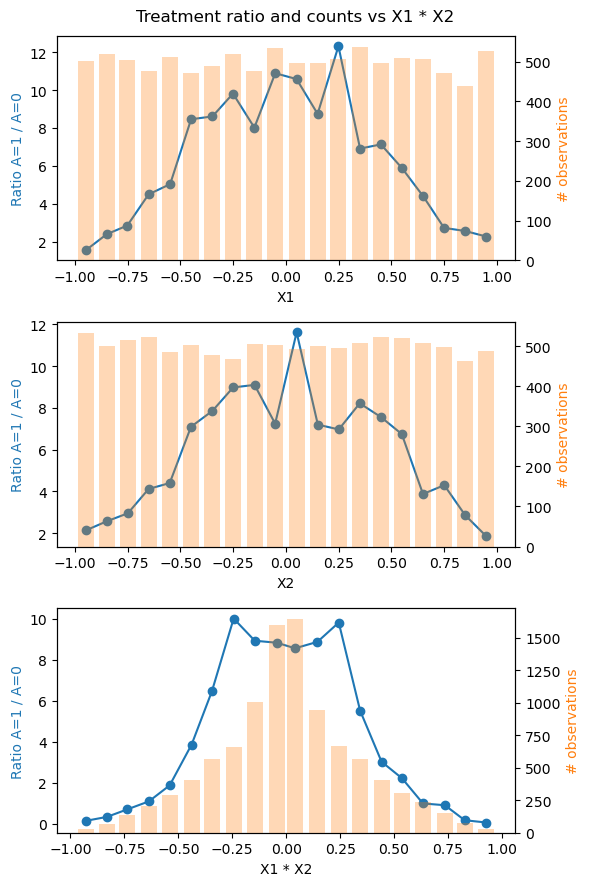

In [9]:
def plot_treatment_ratio_vs_features(X, A, n_bins: int = 20):
    x1 = X[:, 0]
    x2 = X[:, 1]
    x1x2 = x1 * x2
    features = [x1, x2, x1x2]
    names = ["X1", "X2", "X1 * X2"]

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 9))

    for feat, name in zip(features, names):
        df = pd.DataFrame({"feature": feat, "A": A})

        bins = np.linspace(df["feature"].min(), df["feature"].max(), n_bins + 1)
        df["bin"] = pd.cut(df["feature"], bins=bins, include_lowest=True)

        grouped = df.groupby("bin")
        n1 = grouped["A"].sum()
        n0 = grouped["A"].count() - n1
        counts = grouped["A"].count()
        ratio = (n1 + 1e-6) / (n0 + 1e-6)
        centers = grouped["feature"].mean()

        ax1 = axes[names.index(name)]
        ax2 = ax1.twinx()

        ax1.plot(centers, ratio, marker="o", color="tab:blue", label="A=1 / A=0")
        ax2.bar(centers, counts, width=(centers.max() - centers.min()) / n_bins * 0.8,
                alpha=0.3, color="tab:orange", label="# obs")

        ax1.set_xlabel(name)
        ax1.set_ylabel("Ratio A=1 / A=0", color="tab:blue")
        ax2.set_ylabel("# observations", color="tab:orange")
        fig.suptitle(f"Treatment ratio and counts vs {name}")
    fig.tight_layout()
    plt.show()

plot_treatment_ratio_vs_features(twosample.X_e, twosample.A_e)

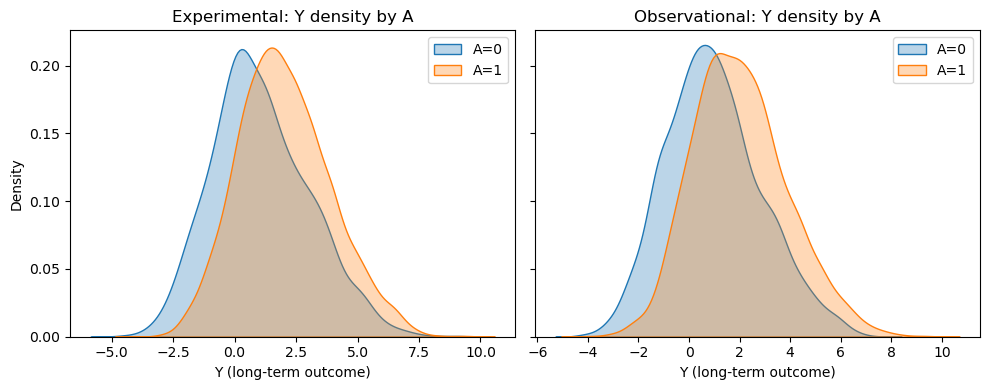

In [10]:
def plot_long_term_outcome_densities(dataset):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    # Experimental: Y_e with A_e
    for a_val, label, color in [(0, "A=0", "tab:blue"), (1, "A=1", "tab:orange")]:
        sns.kdeplot(
            dataset.Y_e[dataset.A_e == a_val],
            ax=axes[0],
            label=label,
            color=color,
            fill=True,
            alpha=0.3,
        )
    axes[0].set_title("Experimental: Y density by A")
    axes[0].set_xlabel("Y (long-term outcome)")
    axes[0].legend()

    # Observational: Y_o with A_o
    for a_val, label, color in [(0, "A=0", "tab:blue"), (1, "A=1", "tab:orange")]:
        sns.kdeplot(
            dataset.Y_o[dataset.A_o == a_val],
            ax=axes[1],
            label=label,
            color=color,
            fill=True,
            alpha=0.3,
        )
    axes[1].set_title("Observational: Y density by A")
    axes[1].set_xlabel("Y (long-term outcome)")
    axes[1].legend()

    fig.tight_layout()
    plt.show()

# Call with full synthetic dataset (includes A_o and Y_e)
plot_long_term_outcome_densities(dataset)

C:\Users\ma\AppData\Local\Temp\ipykernel_17384\453195106.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["bin", "A"]).agg(
C:\Users\ma\AppData\Local\Temp\ipykernel_17384\453195106.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["bin", "A"]).agg(


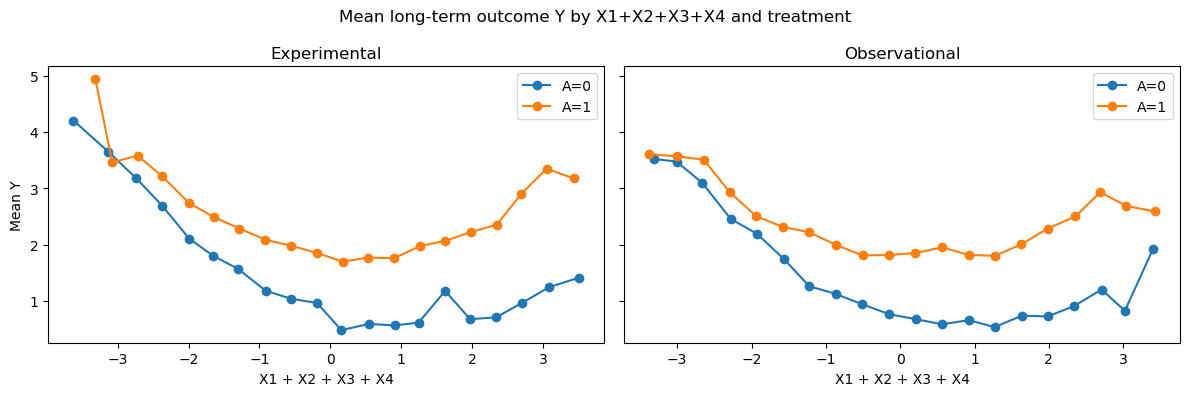

In [12]:
def plot_y_by_xsum_and_treatment(dataset, n_bins: int = 10):
    """
    Plot mean long-term outcome Y by bins of X1+X2+X3+X4,
    with separate curves for A=0 and A=1, for experimental and observational data.
    """
    def _compute_means(X, Y, A, n_bins):
        xsum = X[:, 0] + X[:, 1] + X[:, 2] + X[:, 3]
        df = pd.DataFrame({"xsum": xsum, "Y": Y, "A": A})
        bins = np.linspace(df["xsum"].min(), df["xsum"].max(), n_bins + 1)
        df["bin"] = pd.cut(df["xsum"], bins=bins, include_lowest=True)

        grouped = df.groupby(["bin", "A"]).agg(
            mean_Y=("Y", "mean"),
            mean_xsum=("xsum", "mean"),
        ).reset_index()

        results = {}
        for a_val in [0, 1]:
            sub = grouped[grouped["A"] == a_val]
            results[a_val] = (sub["mean_xsum"].to_numpy(), sub["mean_Y"].to_numpy())
        return results

    # Experimental (uses full dataset object: X_e, Y_e, A_e)
    means_e = _compute_means(dataset.X_e, dataset.Y_e, dataset.A_e, n_bins)
    # Observational
    means_o = _compute_means(dataset.X_o, dataset.Y_o, dataset.A_o, n_bins)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    # Experimental
    ax = axes[0]
    for a_val, color in [(0, "tab:blue"), (1, "tab:orange")]:
        xs, ys = means_e[a_val]
        ax.plot(xs, ys, marker="o", color=color, label=f"A={a_val}")
    ax.set_title("Experimental")
    ax.set_xlabel("X1 + X2 + X3 + X4")
    ax.set_ylabel("Mean Y")
    ax.legend()

    # Observational
    ax = axes[1]
    for a_val, color in [(0, "tab:blue"), (1, "tab:orange")]:
        xs, ys = means_o[a_val]
        ax.plot(xs, ys, marker="o", color=color, label=f"A={a_val}")
    ax.set_title("Observational")
    ax.set_xlabel("X1 + X2 + X3 + X4")
    ax.legend()

    fig.suptitle("Mean long-term outcome Y by X1+X2+X3+X4 and treatment")
    fig.tight_layout()
    plt.show()

# Call it:
plot_y_by_xsum_and_treatment(dataset, n_bins = 20)


In [7]:
learner = train_t_learner(cfg, train_data)
logger.info('Finished training T-learner')
#generate test set
test_data, ground_truth = dataset.sample()
mse = evaluate_mse(learner, test_data, ground_truth)
metrics = {'cate_mse': mse}
logger.info('Final metrics: %s', metrics)

INFO:__main__:Initializing T-learner model and building nuisance models
INFO:__main__:Finished training T-learner
INFO:__main__:Predicting CATE on experimental covariates
INFO:__main__:Computed CATE MSE: 0.169112
INFO:__main__:Final metrics: {'cate_mse': 0.1691118464838305}


In [5]:
cfg_r = load_config(dataset="setupA", model="R-learner", trainer="default", config_root=root / "config")
rlearner = train_r_learner(cfg_r, train_data)
logger.info('Finished training R-learner')
mse = evaluate_mse(rlearner, test_data, ground_truth)
logger.info(f'R-learner MSE: {mse:.4f}')

NameError: name 'train_r_learner' is not defined